# Logistic Regression Model using BOW
**Train on Mendeley data, Test on Kaggle data**

In [10]:
import json
import numpy as np
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
# ============ LOAD DATA ============
print("Loading data...")

# Load training data (Mendeley) 
with open('../tokenization/tokens/BOW_mendeley.json', 'r', encoding='utf-8') as f:
    train_data = json.load(f)

# Load test data (Kaggle)
with open('../tokenization/tokens/BOW_kaggle.json', 'r', encoding='utf-8') as f:
    test_data = json.load(f)

print(f"Training samples (Mendeley): {len(train_data):,}")
print(f"Test samples (Kaggle): {len(test_data):,}")

Loading data...
Training samples (Mendeley): 53,920
Test samples (Kaggle): 117,458


In [ ]:
# ============ PREPARE DATA ============
# Extract features and labels
X_train = [item['BOW'] for item in train_data]
y_train = [item['recommend'] for item in train_data]

X_test = [item['BOW'] for item in test_data]
y_test = [item['recommend'] for item in test_data]

print(f"Training set - Positive: {sum(y_train):,}, Negative: {len(y_train) - sum(y_train):,}")
print(f"Test set - Positive: {sum(y_test):,}, Negative: {len(y_test) - sum(y_test):,}")

Training set - Positive: 26,960, Negative: 26,960
Test set - Positive: 55,789, Negative: 61,669


In [14]:
# ============ CREATE BOW FEATURES ============
print("Creating BOW features...")
dict_vectorizer = DictVectorizer()
X_train_BOW = dict_vectorizer.fit_transform(X_train)
X_test_BOW = dict_vectorizer.transform(X_test)

print(f"BOW matrix vocabulary size: {len(dict_vectorizer.vocabulary_):,}")
print(f"Training matrix shape: {X_train_BOW.shape}")
print(f"Test matrix shape: {X_test_BOW.shape}")

Creating BOW features...
BOW matrix vocabulary size: 36,601
Training matrix shape: (53920, 36601)
Test matrix shape: (117458, 36601)


In [15]:
# ============ TRAIN MODEL ============
print("Training Logistic Regression model...")
model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_BOW, y_train)
print("Training complete!")

Training Logistic Regression model...


c:\Users\yuhan\miniconda3\envs\cs175\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Training complete!


In [16]:
# ============ EVALUATE ON TEST SET ============
print("=" * 50)
print("EVALUATION ON KAGGLE TEST SET")
print("=" * 50)

y_pred = model.predict(X_test_BOW)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

EVALUATION ON KAGGLE TEST SET

Accuracy:  0.7580
Precision: 0.7267
Recall:    0.7859
F1 Score:  0.7552

--- Classification Report ---
              precision    recall  f1-score   support

    Negative       0.79      0.73      0.76     61669
    Positive       0.73      0.79      0.76     55789

    accuracy                           0.76    117458
   macro avg       0.76      0.76      0.76    117458
weighted avg       0.76      0.76      0.76    117458



--- Confusion Matrix ---
[[45182 16487]
 [11943 43846]]


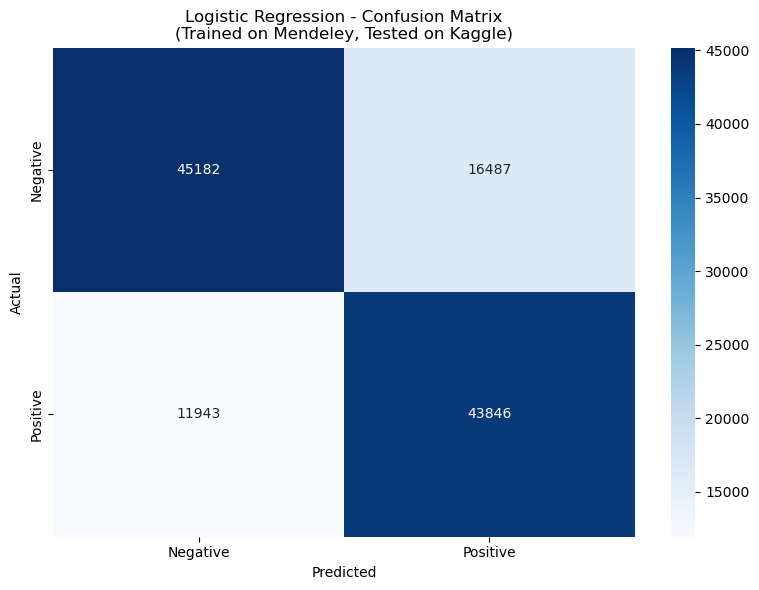

In [17]:
# ============ CONFUSION MATRIX ============
cm = confusion_matrix(y_test, y_pred)
print("--- Confusion Matrix ---")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix\n(Trained on Mendeley, Tested on Kaggle)')
plt.tight_layout()
plt.show()

In [18]:
# ============ TOP PREDICTIVE FEATURES ============
feature_names = dict_vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

# Top positive indicators
top_positive_idx = np.argsort(coefficients)[-15:][::-1]
print("Top 15 words indicating POSITIVE reviews:")
for idx in top_positive_idx:
    print(f"  {feature_names[idx]}: {coefficients[idx]:.4f}")

# Top negative indicators
top_negative_idx = np.argsort(coefficients)[:15]
print("\nTop 15 words indicating NEGATIVE reviews:")
for idx in top_negative_idx:
    print(f"  {feature_names[idx]}: {coefficients[idx]:.4f}")

Top 15 words indicating POSITIVE reviews:
  masterpiece: 2.1777
  underrated: 2.1035
  intrigue: 2.0509
  complain: 1.9340
  april: 1.9135
  unknown: 1.8103
  whine: 1.7902
  entertaining: 1.7822
  upcoming: 1.7713
  dope: 1.7480
  sensible: 1.7430
  yahoo: 1.7396
  annihilate: 1.6944
  beautifully: 1.6877
  delightful: 1.6817

Top 15 words indicating NEGATIVE reviews:
  mildly: -2.2573
  unenjoyable: -2.1865
  disappointing: -2.1783
  pale: -2.0859
  scam: -1.9929
  glare: -1.9801
  glaring: -1.9559
  category: -1.9240
  boring: -1.9005
  chore: -1.8187
  deceive: -1.8056
  worse: -1.8036
  refund: -1.7976
  repetative: -1.7860
  rigid: -1.7703


In [19]:
# ============ RESULTS SUMMARY ============
print("=" * 50)
print("RESULTS SUMMARY")
print("=" * 50)
print(f"Model: Logistic Regression")
print(f"Train data: Mendeley cleaned ({len(train_data):,} samples)")
print(f"Test data: Kaggle cleaned ({len(test_data):,} samples)")
print(f"\nMetrics:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")

RESULTS SUMMARY
Model: Logistic Regression
Train data: Mendeley cleaned (53,920 samples)
Test data: Kaggle cleaned (117,458 samples)

Metrics:
  Accuracy:  0.7580
  Precision: 0.7267
  Recall:    0.7859
  F1 Score:  0.7552
